In [ ]:
!pip install kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mahdimashayekhi/disease-risk-from-daily-habits")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'disease-risk-from-daily-habits' dataset.
Path to dataset files: /kaggle/input/disease-risk-from-daily-habits


In [ ]:
!pip install catboost

In [ ]:
#import library
import pandas as pd
import os

# Lihat isi folder dataset
print(os.listdir(path))

['health_lifestyle_classification.csv']


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from catboost import CatBoostClassifier

In [ ]:
df = pd.read_csv(path + "/health_lifestyle_classification.csv")
df.head()

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,sleep_quality,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,alcohol_consumption,smoking_level,water_intake,screen_time,stress_level,mental_health_score,mental_health_support,education_level,job_type,occupation,income,diet_type,exercise_type,device_usage,healthcare_access,insurance,sunlight_exposure,meals_per_day,caffeine_intake,family_history,pet_owner,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage,target
0,1,56,Male,173.416872,56.886640,18.915925,18.915925,56.747776,18.989117,72.165130,118.264254,60.749825,214.580523,103.008176,NaN,6.475885,Fair,7.671313,0.356918,13320.942595,2673.546960,44.476887,NaN,Non-smoker,1.694262,5.003963,2,8,No,PhD,Tech,Farmer,6759.821719,Vegan,Strength,High,Poor,No,High,5,Moderate,No,Yes,0,1.0,5.5,-2.275502,healthy
1,2,69,Female,163.207380,97.799859,36.716278,36.716278,110.148833,36.511417,85.598889,117.917986,66.463696,115.794002,116.905134,10.131597,8.428410,Good,9.515198,0.568219,11911.201401,2650.376972,74.663405,Regularly,Light,0.716409,5.925455,3,9,No,High School,Office,Engineer,6240.517690,Vegan,Cardio,Moderate,Moderate,No,High,5,High,Yes,No,0,1.0,5.5,6.239340,healthy
2,3,46,Male,177.281966,80.687562,25.673050,25.673050,77.019151,25.587429,90.295030,123.073698,76.043212,138.134787,89.180302,NaN,5.702164,Poor,5.829853,3.764406,2974.035375,1746.755144,19.702382,Regularly,Heavy,2.487900,4.371250,0,1,No,Master,Office,Teacher,3429.179266,Vegan,Cardio,High,Good,Yes,High,4,Moderate,No,No,0,1.0,5.5,5.423737,healthy
3,4,32,Female,172.101255,63.142868,21.318480,21.318480,63.955440,21.177109,100.504211,148.173453,68.781981,203.017447,128.375798,18.733179,5.188316,Good,9.489693,0.889474,5321.539497,2034.193242,82.580050,Occasionally,Heavy,2.643335,4.116064,10,4,No,Master,Labor,Teacher,2618.503534,Vegetarian,Mixed,Low,Moderate,No,High,1,NaN,No,Yes,0,1.0,5.5,8.388611,healthy
4,5,60,Female,163.608816,40.000000,14.943302,14.943302,44.829907,14.844299,69.021150,150.613181,92.335358,200.412439,94.813332,16.038701,7.912514,Good,7.275450,2.901608,9791.376712,2386.210257,45.961322,NaN,Heavy,1.968393,3.180087,9,7,Yes,Master,Unemployed,Doctor,3662.086276,Vegan,NaN,Low,Moderate,Yes,High,1,High,Yes,Yes,0,1.0,5.5,0.332622,healthy


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   survey_code               100000 non-null  int64  
 1   age                       100000 non-null  int64  
 2   gender                    100000 non-null  object 
 3   height                    100000 non-null  float64
 4   weight                    100000 non-null  float64
 5   bmi                       100000 non-null  float64
 6   bmi_estimated             100000 non-null  float64
 7   bmi_scaled                100000 non-null  float64
 8   bmi_corrected             100000 non-null  float64
 9   waist_size                100000 non-null  float64
 10  blood_pressure            92331 non-null   float64
 11  heart_rate                85997 non-null   float64
 12  cholesterol               100000 non-null  float64
 13  glucose                   100000 non-null  fl

In [ ]:
pd.set_option('display.max_columns', None)
df.head()

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,sleep_quality,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,alcohol_consumption,smoking_level,water_intake,screen_time,stress_level,mental_health_score,mental_health_support,education_level,job_type,occupation,income,diet_type,exercise_type,device_usage,healthcare_access,insurance,sunlight_exposure,meals_per_day,caffeine_intake,family_history,pet_owner,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage,target
0,1,56,Male,173.416872,56.886640,18.915925,18.915925,56.747776,18.989117,72.165130,118.264254,60.749825,214.580523,103.008176,NaN,6.475885,Fair,7.671313,0.356918,13320.942595,2673.546960,44.476887,NaN,Non-smoker,1.694262,5.003963,2,8,No,PhD,Tech,Farmer,6759.821719,Vegan,Strength,High,Poor,No,High,5,Moderate,No,Yes,0,1.0,5.5,-2.275502,healthy
1,2,69,Female,163.207380,97.799859,36.716278,36.716278,110.148833,36.511417,85.598889,117.917986,66.463696,115.794002,116.905134,10.131597,8.428410,Good,9.515198,0.568219,11911.201401,2650.376972,74.663405,Regularly,Light,0.716409,5.925455,3,9,No,High School,Office,Engineer,6240.517690,Vegan,Cardio,Moderate,Moderate,No,High,5,High,Yes,No,0,1.0,5.5,6.239340,healthy
2,3,46,Male,177.281966,80.687562,25.673050,25.673050,77.019151,25.587429,90.295030,123.073698,76.043212,138.134787,89.180302,NaN,5.702164,Poor,5.829853,3.764406,2974.035375,1746.755144,19.702382,Regularly,Heavy,2.487900,4.371250,0,1,No,Master,Office,Teacher,3429.179266,Vegan,Cardio,High,Good,Yes,High,4,Moderate,No,No,0,1.0,5.5,5.423737,healthy
3,4,32,Female,172.101255,63.142868,21.318480,21.318480,63.955440,21.177109,100.504211,148.173453,68.781981,203.017447,128.375798,18.733179,5.188316,Good,9.489693,0.889474,5321.539497,2034.193242,82.580050,Occasionally,Heavy,2.643335,4.116064,10,4,No,Master,Labor,Teacher,2618.503534,Vegetarian,Mixed,Low,Moderate,No,High,1,NaN,No,Yes,0,1.0,5.5,8.388611,healthy
4,5,60,Female,163.608816,40.000000,14.943302,14.943302,44.829907,14.844299,69.021150,150.613181,92.335358,200.412439,94.813332,16.038701,7.912514,Good,7.275450,2.901608,9791.376712,2386.210257,45.961322,NaN,Heavy,1.968393,3.180087,9,7,Yes,Master,Unemployed,Doctor,3662.086276,Vegan,NaN,Low,Moderate,Yes,High,1,High,Yes,Yes,0,1.0,5.5,0.332622,healthy


In [ ]:
df.isnull().sum()

,0
survey_code,0
age,0
gender,0
height,0
weight,0
bmi,0
bmi_estimated,0
bmi_scaled,0
bmi_corrected,0
waist_size,0


In [ ]:
drop_cols = [
    'survey_code','bmi_estimated','bmi_scaled','bmi_corrected',
    'mental_health_score','mental_health_support','education_level',
    'job_type','occupation','income','healthcare_access','insurance',
    'sunlight_exposure','family_history','pet_owner',
    'electrolyte_level','gene_marker_flag','environmental_risk_score',
    'daily_supplement_dosage'
]
df = df.drop(columns=drop_cols)

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include='object').columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
height,0
weight,0
bmi,0
waist_size,0
blood_pressure,0
heart_rate,0
cholesterol,0
glucose,0


In [ ]:
df['target'] = df['target'].map({
    'healthy':0,
    'diseased':1
})



df['target'].value_counts()

,count
target,
0,70097
1,29903


In [ ]:
X = df.drop('target', axis=1)
y = df['target']

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
height,0
weight,0
bmi,0
waist_size,0
blood_pressure,0
heart_rate,0
cholesterol,0
glucose,0


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cat_features = X.select_dtypes(include=['object','category']).columns.tolist()

In [ ]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=4000,
    learning_rate=0.02,
    depth=8,
    l2_leaf_reg=15,
    random_strength=3,
    auto_class_weights='Balanced',
    eval_metric='AUC',
    random_state=42,
    verbose=200
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=300
)

0:	test: 0.4999825	best: 0.4999825 (0)	total: 404ms	remaining: 26m 56s
200:	test: 0.5065344	best: 0.5070823 (192)	total: 45.5s	remaining: 14m 20s
400:	test: 0.5043651	best: 0.5070823 (192)	total: 1m 14s	remaining: 11m 7s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.5070822686
bestIteration = 192

Shrink model to first 193 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=8, eval_metric='AUC', iterations=4000, l2_leaf_reg=15, learning_rate=0.02, random_state=42, random_strength=3, verbose=200)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.5070822685895783


In [ ]:
from sklearn.metrics import f1_score

best_f1 = 0
best_threshold = 0

for t in np.arange(0.2, 0.8, 0.05):
    y_pred = (y_prob > t).astype(int)
    score = f1_score(y_test, y_pred)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

Best threshold: 0.2
Best F1: 0.46041337900773643


In [ ]:
y_pred_final = (y_prob > best_threshold).astype(int)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

Accuracy: 0.29905
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     14019
           1       0.30      1.00      0.46      5981

    accuracy                           0.30     20000
   macro avg       0.15      0.50      0.23     20000
weighted avg       0.09      0.30      0.14     20000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
corr = df.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(corr)

target               1.000000
age                  0.006951
weight               0.002626
bmi                  0.002527
sleep_hours          0.001663
cholesterol          0.001529
waist_size           0.000553
glucose              0.000483
calorie_intake       0.000254
screen_time          0.000134
insulin              0.000124
heart_rate          -0.000055
sugar_intake        -0.000398
stress_level        -0.000767
physical_activity   -0.001298
height              -0.001453
water_intake        -0.001848
blood_pressure      -0.002537
meals_per_day       -0.002914
daily_steps         -0.004842
work_hours          -0.010906
Name: target, dtype: float64


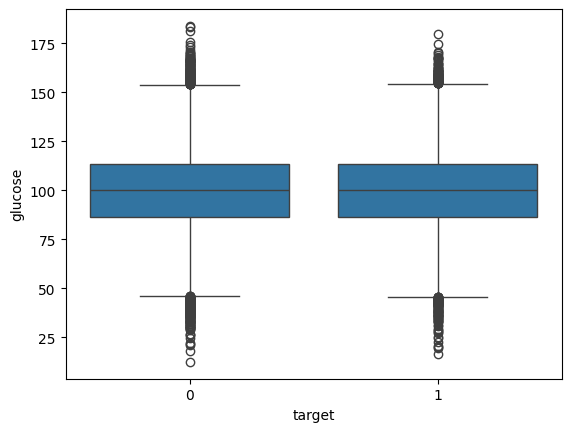

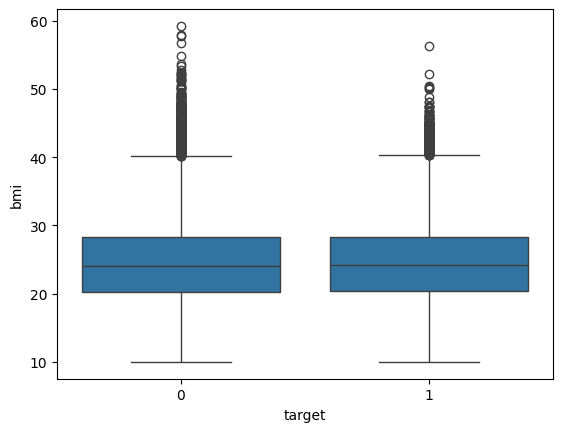

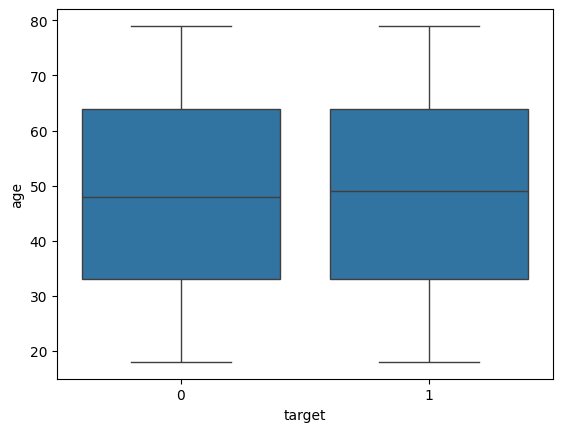

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='target', y='glucose', data=df)
plt.show()

sns.boxplot(x='target', y='bmi', data=df)
plt.show()

sns.boxplot(x='target', y='age', data=df)
plt.show()